In [1]:
import torchlm
from torchlm.tools import faceboxesv2
from torchlm.models import pipnet
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from scene.colmap_loader import read_extrinsics_text, read_intrinsics_text, qvec2rotmat, \
            read_extrinsics_binary, read_intrinsics_binary
from tqdm import tqdm
# 视角 5 7 9 11 13


def read_image(image_path):
    images=[]
    files = os.listdir(image_path)
    files.sort()
    for file in files:
        image = cv2.imread(image_path+file)
        images.append(image)
    return images

def getkeypoint33(landmarks):
    # # 眉毛 10个
    # sub0 = landmarks[:,33:38][:,::2]  
    # sub1 = landmarks[:,38:51][:,::2]
    # # 眼睛 8个
    # sub2 = landmarks[:,60:76][:,::2]
    # # 鼻子 9个
    # sub3 = landmarks[:,51:60]
    # # 嘴巴 6个
    # sub4 = landmarks[:,76:88][:,::2]
    # sub0 = landmarks[:,60:61] # 右眼角1
    # sub1 = landmarks[:,76:77] # 右嘴角1

    # sub0 = landmarks[:,72:73] # 左眼眼1
    # sub1 = landmarks[:,82:83] # 左嘴角1

    sub0 = landmarks[:,68:69] 
    sub1 = landmarks[:,64:65] 
    
    LM = np.concatenate((sub0,sub1),axis=1)
    return LM

def draw_video(id, keypoints_all_frames, images, cam_id):
    output_video_path = f"./trajectory/{id}/keypoints_trajectory{cam_id.zfill(2)}.mp4"

    keypoints = np.array(keypoints_all_frames)[:, 0, ...]  #(150,1,33,2)->(150,33,2)
    # 绘制关键点运动轨迹并生成视频
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    height, width, layers = images[0].shape
    video = cv2.VideoWriter(output_video_path, fourcc, 30, (width, height))

    for frame_idx in range(keypoints.shape[0]):
        frame = images[frame_idx].copy()
        for point_idx in range(keypoints.shape[1]):
            x = keypoints[:frame_idx + 1, point_idx, 0]
            y = keypoints[:frame_idx + 1, point_idx, 1]
            for i in range(len(x) - 1):
                cv2.line(frame, (int(x[i]), int(y[i])), (int(x[i + 1]), int(y[i + 1])), (0, 255, 0), 5)
        video.write(frame)

    video.release()

def get_landmarks(id, cam_id):
    image_path = f"./data/multipleview/{id}/cam{cam_id.zfill(2)}/"
    output_dir = f"./trajectory/{id}/cam{cam_id.zfill(2)}/"
    output_image=[]
    keypoints_all_frames=[]
    
    torchlm.runtime.bind(
        faceboxesv2(device="cpu")
    )  # set device="cuda" if you want to run with CUDA
    # set map_location="cuda" if you want to run with CUDA
    torchlm.runtime.bind(
        pipnet(
            backbone="resnet101",
            pretrained=True,
            num_nb=10,
            num_lms=98, #98
            net_stride=32,
            input_size=256,
            meanface_type="wflw",
            map_location="cpu",
            checkpoint=None,
        )
    ) # will auto download pretrained weights from latest release if pretrained=True

    images = read_image(image_path)

    for image in images:
        
        #image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        landmarks, bboxes = torchlm.runtime.forward(image)
        landmarks = getkeypoint33(landmarks)
        keypoints_all_frames.append(landmarks)
        

        image = torchlm.utils.draw_landmarks(image, landmarks=landmarks)
        output_image.append(image)

    for idx, image in enumerate(output_image, start=1):
        os.makedirs(output_dir, exist_ok=True)
        cv2.imwrite(output_dir + f"frame_{str(idx).zfill(5)}.jpg", image)
    return keypoints_all_frames, images

def get_k_w2c(datadir, cam_id):
    cameras_extrinsic_file = os.path.join(datadir, "sparse_/images.bin")
    cameras_intrinsic_file = os.path.join(datadir, "sparse_/cameras.bin")
    cam_extrinsics = read_extrinsics_binary(cameras_extrinsic_file)
    cam_intrinsics = read_intrinsics_binary(cameras_intrinsic_file)
    value = f'image{cam_id}.jpg'
    for idx, key in enumerate(cam_extrinsics):
        if cam_extrinsics[key].name == value:
            extr_id = key
            intr_id = cam_extrinsics[key].camera_id

    extr = cam_extrinsics[extr_id]
    R = qvec2rotmat(extr.qvec)
    T = np.array(extr.tvec)
    k = cam_intrinsics[intr_id].params
    k = np.array([[k[0], 0, k[1],0],
                  [0, k[0], k[2],0],
                  [0, 0, 1,0]])
    r =R.T
    tt = -r@T
    extrinsic_matrix = np.hstack([r,tt.reshape(3,1)])
    extrinsic_matrix = np.vstack([extrinsic_matrix,np.array([0,0,0,1])])
    w2c = np.linalg.inv(extrinsic_matrix)
    return k[:3,:3], w2c[:3,:]
# 三角计算
def triangulate_points(P1, P2, pts1, pts2):
    points_4d = cv2.triangulatePoints(P1, P2, pts1.T, pts2.T)
    points_3d = cv2.convertPointsFromHomogeneous(points_4d.T)
    return points_3d

# 重投影
def reproject_points(P, points_3d):
    points_3d_hom = cv2.convertPointsToHomogeneous(points_3d)
    points_3d_hom = points_3d_hom.reshape(-1, 4).T  # Reshape to (4, N)
    points_2d_hom = P.dot(points_3d_hom).T  # Perform the dot product and transpose back
    points_2d = cv2.convertPointsFromHomogeneous(points_2d_hom)
    return points_2d

# 计算重投影误差
def compute_reprojection_error(pts, reproj_pts):
    errors = np.sqrt(np.sum((pts - reproj_pts) ** 2, axis=1))
    return errors

# 过滤误差不符合阈值的点
def filter_points_by_error(points_3d, error1, error2, threshold=1.0):
    # 创建一个新的数组，初始化为 (-1, -1, -1)
    filtered_points_3d = np.full(points_3d.shape, fill_value=(-1, -1, -1), dtype=points_3d.dtype)
    
    # 使用 np.where 来找到满足 (error1 < threshold) 和 (error2 < threshold) 条件的索引
    valid_indices = np.where((error1 < threshold) & (error2 < threshold))[0]
    
   
    # 将满足条件的点从 points_3d 复制到 filtered_points_3d 中
    filtered_points_3d[valid_indices] = points_3d[valid_indices]
    
    # 返回过滤后的 3D 点
    return filtered_points_3d
    

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
id ="031"
landmarks_base, images09 = get_landmarks(id=id, cam_id="9")
datadir = f"./data/multipleview/{id}"
op_dir = f"./trajectory/{id}"

K_base, w2c_base = get_k_w2c(datadir, "9")
# 投影矩阵
P_base = K_base.dot(w2c_base)

landmarks_normal = []
for idx in range(1, 17):
        if idx == 2 or idx == 15 or idx == 9:
            continue
            
        
        landmarks, images = get_landmarks(id=id, cam_id=str(idx))
        landmarks_normal.append(landmarks)
a = np.array(landmarks_normal)
print(a.shape)



(13, 150, 1, 2, 2)


In [ ]:
print(K_base)
print(w2c_base)

In [3]:
PCD_allframe=[]
# 计算150帧的3D点
for frame in tqdm(range(len(images09))):
    a = 0
    Pts3D_all=[]
    Pts_base = np.array(landmarks_base[frame])[0,...] #(1,33,2)->(33,2)
    for idx in range(1, 17):
        #  当测左边脸或右边脸的关键点时，得确保筛选有用的视角
        if idx ==2 or idx == 15  or idx == 9:
            continue
            
        K, w2c = get_k_w2c(datadir, str(idx))
        # 投影矩阵
        P = K.dot(w2c)
        Pts = np.array(landmarks_normal[a][frame])[0,...]
        points_3d = triangulate_points(P_base, P, Pts_base, Pts)
        
        # 计算重投影
        reproj_pts1 = reproject_points(P_base, points_3d)
        reproj_pts2 = reproject_points(P, points_3d)
        # 计算重投影误差
        error1 = compute_reprojection_error(Pts_base, reproj_pts1[:,0,...])
        error2 = compute_reprojection_error(Pts, reproj_pts2[:,0,...])
        
        
        # 过滤误差不符合阈值的点
        filtered_points_3d = filter_points_by_error(points_3d[:,0,...], error1, error2, threshold=2.5)
        Pts3D_all.append(filtered_points_3d)
        a+=1
    #print(len(Pts3D_all))
    # 将列表转换为 NumPy 数组，以便进行计算
    points_array = np.array(Pts3D_all)

    #print(points_array.shape)  # (14, 33, 3)
    
    # 点云融合
    P3d_mean=[]
    for i in range(points_array.shape[1]):
        point3d = np.array([0, 0, 0], dtype=float)
        idx = 0
        for j in range(points_array.shape[0]):
            if True in (points_array[j,i] != [-1,-1,-1]):
                point3d += points_array[j,i]
                idx += 1
        #print(f"第{i+1}个点的个数为：{idx}")
        point3d = point3d/idx
        P3d_mean.append(point3d)
    PCD_allframe.append(np.array(P3d_mean))

100%|██████████| 150/150 [00:12<00:00, 12.39it/s]


In [4]:
PCD_allframe = np.array(PCD_allframe)
print(PCD_allframe.shape)


(150, 2, 3)


### 将三维坐标保存为JSON格式

In [5]:

import json
data_list = PCD_allframe.tolist()


with open(os.path.join(op_dir,'_xyz.json'), 'w') as file:
    json.dump(data_list, file)

# 读取 数据
# import json
# import numpy as np

with open(os.path.join(op_dir,'_xyz.json'), 'r') as file:
    data_list = json.load(file)

# 将 Python 列表转换回 numpy 数组
data = np.array(data_list)

print(data)


[[[ 0.46694793 -0.34961186  6.96285168]
  [ 0.2112461  -0.36425807  6.97909168]]

 [[ 0.46724896 -0.34968143  6.96272026]
  [ 0.21077506 -0.36439043  6.97955803]]

 [[ 0.46634436 -0.34986449  6.96262012]
  [ 0.21103482 -0.36443049  6.97962005]]

 [[ 0.46607262 -0.34983111  6.96335093]
  [ 0.21067036 -0.36440362  6.97940786]]

 [[ 0.46532016 -0.34969343  6.96368853]
  [ 0.21132191 -0.36429905  6.98051357]]

 [[ 0.4655174  -0.34931712  6.96537032]
  [ 0.21089909 -0.36461819  6.98106205]]

 [[ 0.46544583 -0.35011295  6.96741252]
  [ 0.21055798 -0.3649785   6.98168505]]

 [[ 0.46634971 -0.35051478  6.96633301]
  [ 0.21032564 -0.36478872  6.983736  ]]

 [[ 0.468485   -0.35093596  6.9666565 ]
  [ 0.21062444 -0.36444056  6.98333608]]

 [[ 0.46932309 -0.35233984  6.96576949]
  [ 0.20996348 -0.3652837   6.98364929]]

 [[ 0.47042698 -0.35390892  6.96890458]
  [ 0.20865999 -0.36753446  6.98439019]]

 [[ 0.46633344 -0.35436655  6.97109733]
  [ 0.2099446  -0.37006924  6.98542973]]

 [[ 0.47174011 -

### 保存三维点轨迹坐标可视化

In [6]:
from matplotlib.animation import FuncAnimation

# 定义旋转角度（以度为单位）
angle =-90
angle1 = 30
# 将角度转换为弧度
theta = np.radians(angle)
theta1 = np.radians(angle1)

# 定义绕 x 轴的旋转矩阵
Rx = np.array([
    [1, 0, 0],
    [0, np.cos(theta), -np.sin(theta)],
    [0, np.sin(theta), np.cos(theta)]
])
Rz = np.array([
    [np.cos(theta1), -np.sin(theta1), 0],
    [np.sin(theta1), np.cos(theta1), 0],
    [0, 0, 1]
])
# 应用旋转矩阵
# 定义旋转角度（例如45度）
theta = np.radians(45) # 将角度从度转换为弧度
# 定义绕x轴旋转的旋转矩阵

# 创建一个新的数组来存储旋转后的点云
rotated_points = np.zeros_like(PCD_allframe)
# 遍历每个点云进行旋转
for i in range(PCD_allframe.shape[0]):
    rotated_points[i] = np.dot(PCD_allframe[i], Rx.T)
    rotated_points[i] = np.dot(rotated_points[i], Rz.T)

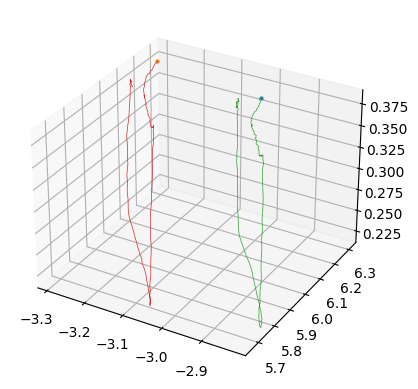

In [7]:
# 创建画布和轴
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# 初始化点云和轨迹
points = [ax.plot([], [], [], 'o', markersize=2)[0] for _ in range(rotated_points.shape[1])]
trajectories = [ax.plot([], [], [], '-', linewidth=0.5)[0] for _ in range(rotated_points.shape[1])]

# 初始化函数
def init():
    ax.set_xlim(np.min(rotated_points[:, :, 0]), np.max(rotated_points[:, :, 0]))
    ax.set_ylim(np.min(rotated_points[:, :, 1]), np.max(rotated_points[:, :, 1]))
    ax.set_zlim(np.min(rotated_points[:, :, 2]), np.max(rotated_points[:, :, 2]))
    return points + trajectories

# 更新函数
def update(frame):
    for i in range(rotated_points.shape[1]):
        x_frame = rotated_points[frame, i, 0]
        y_frame = rotated_points[frame, i, 1]
        z_frame = rotated_points[frame, i, 2]
        
        points[i].set_data([x_frame], [y_frame])
        points[i].set_3d_properties([z_frame], 'z')
        
        if frame > 0:
            x_traj, y_traj, z_traj = trajectories[i].get_data_3d()
            x_traj = np.concatenate((x_traj, [x_frame]))
            y_traj = np.concatenate((y_traj, [y_frame]))
            z_traj = np.concatenate((z_traj, [z_frame]))
        else:
            x_traj, y_traj, z_traj = [x_frame], [y_frame], [z_frame]
        
        trajectories[i].set_data(x_traj, y_traj)
        trajectories[i].set_3d_properties(z_traj, 'z')
    
    return points + trajectories

# 创建动画
ani = FuncAnimation(fig, update, frames=len(rotated_points), init_func=init, blit=True, interval=50)

# 保存动画为GIF文件（可选）

ani.save(os.path.join(op_dir,'point_cloud_animation.gif'), writer='pillow')

# 显示动画
plt.show()

In [8]:
draw_video(id, landmarks_base, images09, "09")

## 下面是草稿

In [ ]:
# 查看 点云轨迹
from mpl_toolkits.mplot3d import Axes3D

# # 定义旋转角度（以度为单位）
# angle =-90
# angle1 = 30
# # 将角度转换为弧度
# theta = np.radians(angle)
# theta1 = np.radians(angle1)
# # 定义绕x轴旋转的旋转矩阵
# rotation_matrix = np.array([
#     [1, 0, 0],
#     [0, np.cos(theta), -np.sin(theta)],
#     [0, np.sin(theta), np.cos(theta)]
# ])
# # 定义绕z轴旋转的旋转矩阵
# rotation_matrix_z = np.array([
#     [np.cos(theta1), -np.sin(theta1), 0],
#     [np.sin(theta1), np.cos(theta1), 0],
#     [0, 0, 1]
# ])

# #xyz = points_3d[:,0,...]
# xyz = np.array(P3d_mean)
# xyz_rotated = np.dot(xyz, rotation_matrix.T)
# xyz_rotated = np.dot(xyz_rotated, rotation_matrix_z.T)
xyz_rotated = rotated_points[0]

# 创建一个3D图形
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# 绘制旋转后的点云
ax.scatter(xyz_rotated[:, 0], xyz_rotated[:, 1], xyz_rotated[:, 2], c='b', marker='o')

# 设置轴标签
ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')

# 显示图形
plt.show()

In [ ]:
# K09 = np.array([[4184.414355323921, 0, 550.0], [0, 4181.32407276664, 802.0], [0, 0, 1]])
# w2c09 = np.array([
#                 [ 0.99846471, -0.05052245, -0.02270904, -0.0244114 ],
#                 [ 0.03071914,  0.84620705, -0.53196801,  1.59264421],
#                 [ 0.04609288,  0.53045368,  0.84645989,  0.65208295],
#                 ])
# K05 = np.array([[4274.547670739889, 0, 550.0], [0, 4282.248760053751, 802.0], [0, 0, 1]])
# w2c05 = np.array([
#                 [ 0.9480082,   0.07770057,  0.30861476, -2.72893667],
#                 [ 0.09785367,  0.85158955, -0.51499505,  1.48849121],
#                 [-0.30282851,  0.51841862,  0.79971059,  1.5575665 ],
#              ])



points1 = np.array(landmarks09[0])[0,...] #(1,33,2)->(33,2)
points2 = np.array(landmarks05[0])[0,...]
P1 = K09.dot(w2c09)
P2 = K05.dot(w2c05)

def triangulate_points(P1, P2, pts1, pts2):
    points_4d = cv2.triangulatePoints(P1, P2, pts1.T, pts2.T)
    points_3d = cv2.convertPointsFromHomogeneous(points_4d.T)
    return points_3d

points_3d = triangulate_points(P1, P2, points1, points2)
#print(points_3d)
# 重投影
def reproject_points(P, points_3d):
    points_3d_hom = cv2.convertPointsToHomogeneous(points_3d)
    points_3d_hom = points_3d_hom.reshape(-1, 4).T  # Reshape to (4, N)
    points_2d_hom = P.dot(points_3d_hom).T  # Perform the dot product and transpose back
    points_2d = cv2.convertPointsFromHomogeneous(points_2d_hom)
    return points_2d
reproj_pts1 = reproject_points(P1, points_3d)
reproj_pts2 = reproject_points(P2, points_3d)

# 计算重投影误差
def compute_reprojection_error(pts, reproj_pts):
    errors = np.sqrt(np.sum((pts - reproj_pts) ** 2, axis=1))
    return errors

error1 = compute_reprojection_error(points1, reproj_pts1[:,0,...])
error2 = compute_reprojection_error(points2, reproj_pts2[:,0,...])



def filter_points_by_error(points_3d, error1, error2, threshold=1.0):
    # 创建一个新的数组，初始化为 (-1, -1, -1)
    filtered_points_3d = np.full(points_3d.shape, fill_value=(-1, -1, -1), dtype=points_3d.dtype)
    
    # 使用 np.where 来找到满足 (error1 < threshold) 和 (error2 < threshold) 条件的索引
    valid_indices = np.where((error1 < threshold) & (error2 < threshold))[0]
    
   
    # 将满足条件的点从 points_3d 复制到 filtered_points_3d 中
    filtered_points_3d[valid_indices] = points_3d[valid_indices]
    
    # 返回过滤后的 3D 点
    return filtered_points_3d

filtered_points_3d = filter_points_by_error(points_3d[:,0,...], error1, error2, threshold=2.5)

print(filtered_points_3d)


In [ ]:
#绘制带关键点轨迹的视频

import matplotlib.pyplot as plt
keypoints = np.array(keypoints_all_frames)[:, 0, ...]  #(150,1,33,2)->(150,33,2)
# 绘制关键点运动轨迹并生成视频
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
height, width, layers = images[0].shape
video = cv2.VideoWriter(output_video_path, fourcc, 30, (width, height))

for frame_idx in range(keypoints.shape[0]):
    frame = images[frame_idx].copy()
    for point_idx in range(keypoints.shape[1]):
        x = keypoints[:frame_idx + 1, point_idx, 0]
        y = keypoints[:frame_idx + 1, point_idx, 1]
        for i in range(len(x) - 1):
            cv2.line(frame, (int(x[i]), int(y[i])), (int(x[i + 1]), int(y[i + 1])), (0, 255, 0), 5)
    video.write(frame)

video.release()

In [ ]:
# 不带轨迹的视频

import cv2
import os

# 图片序列所在的目录
image_folder = './data/cam09/'
# 输出视频文件路径
video_name = 'output_video_cam09.mp4'

# 获取图片文件列表并排序
images = [img for img in os.listdir(image_folder) if img.endswith(".jpg")]
images.sort()

# 读取第一张图片以获取视频的宽度和高度
frame = cv2.imread(os.path.join(image_folder, images[0]))
height, width, layers = frame.shape

# 定义视频编码器及输出文件
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
video = cv2.VideoWriter(video_name, fourcc, 30, (width, height))

for image in images:
    video.write(cv2.imread(os.path.join(image_folder, image)))

cv2.destroyAllWindows()
video.release()
